<a href="https://colab.research.google.com/github/mehmetgul/neural-nets-and-deep-learning/blob/main/Homework_and_Programming_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network and Deep Learning — Homework & Programming Assignment 2

**Total Points: 100**

---

## Question 1 [10 Points]

**We learned two linear models — linear regression and logistic regression. Compare both methods. Can we use a linear regression model to detect a person's face in an image? Describe your rationale.**

---

### Answer

**Comparison of Linear Regression vs. Logistic Regression:**

| Aspect | Linear Regression | Logistic Regression |
|--------|-------------------|---------------------|
| **Output** | Continuous real value (−∞ to +∞) | Probability in [0, 1] |
| **Function** | $\hat{y} = \mathbf{w}^T\mathbf{x} + b$ | $\hat{y} = \sigma(\mathbf{w}^T\mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x} + b)}}$ |
| **Loss Function** | Mean Squared Error (MSE) | Binary Cross-Entropy (Log-Loss) |
| **Task** | Regression (predicting quantities) | Classification (predicting class labels) |
| **Decision Boundary** | Not applicable (no threshold) | Linear decision boundary via sigmoid |

**Can we use linear regression for face detection?**

Face detection is fundamentally a **binary classification** task: given an image region, predict "face" or "not face." While it is *technically possible* to train a linear regression model with targets 0 and 1, this approach has serious drawbacks:

1. **Unbounded outputs:** Linear regression outputs can be < 0 or > 1, making them uninterpretable as probabilities. We would need an arbitrary threshold, and the model has no mechanism to learn a calibrated one.

2. **Inappropriate loss function:** MSE penalizes large positive predictions for the positive class, which is counterproductive for classification. The optimization objective does not align with discriminative classification.

3. **Sensitivity to outliers:** Outlier pixels/samples can drastically skew the regression line, degrading classification performance.

4. **No probabilistic interpretation:** Without a sigmoid transformation, we cannot compute meaningful confidence scores.

5. **Linearity limitation:** Faces in images involve highly nonlinear patterns (edges, textures, shapes). A single linear model cannot capture the complex feature interactions required for face detection regardless of whether we use linear or logistic regression. However, logistic regression is still preferable because it at least models the correct output distribution (Bernoulli) for the classification task.

**Conclusion:** Logistic regression is far more appropriate than linear regression for face detection because it naturally handles binary classification with calibrated probabilities. In practice, even logistic regression is too simple for face detection—deep neural networks (e.g., CNNs) are used because they can learn hierarchical, nonlinear feature representations.


## Question 2 [15 Points]

**In logistic regression, we fit an S-shaped curve. Given 9 sample probabilities: 0.34, 0.21, 0.54, 0.45, 0.60, 0.70, 0.80, 0.95, 0.99.**

**(i) What are log odds? Compute log-odds values. [7 Points]**  
**(ii) Compute log-likelihood for this given data. [8 Points]**

---

In [6]:
import numpy as np

# Given probabilities
probs = np.array([0.34, 0.21, 0.54, 0.45, 0.60, 0.70, 0.80, 0.95, 0.99])

# ============================================================
# Part (i): Log-Odds
# ============================================================
# Log-odds (logit) is defined as: log_odds = ln(p / (1 - p))
# It maps probability [0,1] to (-inf, +inf)
# The logit function is the inverse of the sigmoid function.

log_odds = np.log(probs / (1 - probs))

print("=" * 60)
print("Part (i): Log-Odds Computation")
print("=" * 60)
print(f"{'Probability (p)':>15} | {'Odds (p/(1-p))':>15} | {'Log-Odds ln(p/(1-p))':>20}")
print("-" * 60)
for p, lo in zip(probs, log_odds):
    odds = p / (1 - p)
    print(f"{p:>15.2f} | {odds:>15.4f} | {lo:>20.4f}")

print()
print("Log-odds (logit) transforms probability from [0,1] to (-inf, +inf).")
print("Negative log-odds → p < 0.5 (more likely class 0)")
print("Positive log-odds → p > 0.5 (more likely class 1)")
print("Log-odds = 0     → p = 0.5 (equal likelihood)")


Part (i): Log-Odds Computation
Probability (p) |  Odds (p/(1-p)) | Log-Odds ln(p/(1-p))
------------------------------------------------------------
           0.34 |          0.5152 |              -0.6633
           0.21 |          0.2658 |              -1.3249
           0.54 |          1.1739 |               0.1603
           0.45 |          0.8182 |              -0.2007
           0.60 |          1.5000 |               0.4055
           0.70 |          2.3333 |               0.8473
           0.80 |          4.0000 |               1.3863
           0.95 |         19.0000 |               2.9444
           0.99 |         99.0000 |               4.5951

Log-odds (logit) transforms probability from [0,1] to (-inf, +inf).
Negative log-odds → p < 0.5 (more likely class 0)
Positive log-odds → p > 0.5 (more likely class 1)
Log-odds = 0     → p = 0.5 (equal likelihood)


In [7]:
# ============================================================
# Part (ii): Log-Likelihood
# ============================================================
# For logistic regression, the log-likelihood is:
#   LL = sum[ y_i * ln(p_i) + (1 - y_i) * ln(1 - p_i) ]
#
# Since the problem gives probabilities but no explicit labels,
# we assign labels based on the natural threshold: y=1 if p >= 0.5, y=0 otherwise.
# This is the most reasonable assumption given the problem statement.

# Assign labels based on threshold 0.5
labels = (probs >= 0.5).astype(int)

print("=" * 60)
print("Part (ii): Log-Likelihood Computation")
print("=" * 60)
print(f"{'p':>6} | {'y':>3} | {'y*ln(p)':>12} | {'(1-y)*ln(1-p)':>15} | {'Contribution':>12}")
print("-" * 60)

total_ll = 0
for p, y in zip(probs, labels):
    term1 = y * np.log(p)
    term2 = (1 - y) * np.log(1 - p)
    contribution = term1 + term2
    total_ll += contribution
    print(f"{p:>6.2f} | {y:>3d} | {term1:>12.4f} | {term2:>15.4f} | {contribution:>12.4f}")

print("-" * 60)
print(f"{'Total Log-Likelihood':>40} = {total_ll:.4f}")
print()
print(f"Log-Likelihood = {total_ll:.4f}")
print("A higher (less negative) log-likelihood indicates a better model fit.")


Part (ii): Log-Likelihood Computation
     p |   y |      y*ln(p) |   (1-y)*ln(1-p) | Contribution
------------------------------------------------------------
  0.34 |   0 |      -0.0000 |         -0.4155 |      -0.4155
  0.21 |   0 |      -0.0000 |         -0.2357 |      -0.2357
  0.54 |   1 |      -0.6162 |         -0.0000 |      -0.6162
  0.45 |   0 |      -0.0000 |         -0.5978 |      -0.5978
  0.60 |   1 |      -0.5108 |         -0.0000 |      -0.5108
  0.70 |   1 |      -0.3567 |         -0.0000 |      -0.3567
  0.80 |   1 |      -0.2231 |         -0.0000 |      -0.2231
  0.95 |   1 |      -0.0513 |         -0.0000 |      -0.0513
  0.99 |   1 |      -0.0101 |         -0.0000 |      -0.0101
------------------------------------------------------------
                    Total Log-Likelihood = -3.0172

Log-Likelihood = -3.0172
A higher (less negative) log-likelihood indicates a better model fit.


## Question 3 [15 Points]

**Logistic regression is a binary classifier. Can we use it for multiclass classification? Provide detailed rationale and drawbacks.**

---

### Answer

Yes, logistic regression can be extended for multiclass classification via two main strategies:

---

### Strategy 1: One-vs-Rest (OvR) / One-vs-All (OvA)

**Approach:** For K classes, train K separate binary logistic regression classifiers. The $k$-th classifier treats class $k$ as positive and all other classes as negative. At inference, run all K classifiers and select the class with the highest predicted probability.

**Advantages:**
- Simple to implement and parallelize
- Each classifier is a standard binary logistic regression
- Works well when classes are well separated

**Drawbacks:**
- **Class imbalance:** Each binary classifier sees an imbalanced dataset (1 class vs. all others), which can bias predictions
- **Inconsistent probabilities:** The K classifiers are trained independently, so their outputs may not sum to 1 and are not directly comparable
- **Scalability:** Requires training K separate models, which grows linearly with the number of classes

---

### Strategy 2: One-vs-One (OvO)

**Approach:** Train $\binom{K}{2} = \frac{K(K-1)}{2}$ binary classifiers, one for each pair of classes. At inference, use majority voting.

**Advantages:**
- Each classifier is trained on a smaller, balanced subset
- Can be more accurate when decision boundaries between specific class pairs differ significantly

**Drawbacks:**
- **Computational cost:** Number of classifiers grows quadratically ($O(K^2)$)
- **Ambiguity:** Voting can result in ties, requiring a tie-breaking strategy
- **Memory:** Storing $\binom{K}{2}$ models is expensive for large K

---

### Strategy 3: Multinomial (Softmax) Logistic Regression

**Approach:** Generalize logistic regression directly to K classes using the softmax function:

$$P(y = k | \mathbf{x}) = \frac{e^{\mathbf{w}_k^T \mathbf{x} + b_k}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^T \mathbf{x} + b_j}}$$

This is trained end-to-end with cross-entropy loss.

**Advantages:**
- Produces well-calibrated probabilities that sum to 1
- Single unified model — no inconsistency between classifiers
- Naturally handles multiclass without decomposition

**Drawbacks:**
- Assumes linear decision boundaries between all pairs of classes
- May underperform on problems where class boundaries are highly nonlinear
- All classes share the same feature space and model capacity

---

**Summary:** The most principled extension is **Softmax (Multinomial) Logistic Regression**, which naturally generalizes binary logistic regression. OvR and OvO are practical alternatives but introduce inconsistencies and computational overhead.


## Question 4 [10 Points]

**SoftMax classifier: Given logits 3.5, 6.1, −2.9, −1.2 for classes "bus", "truck", "car", "van". Compute probabilities and classify.**

---

In [8]:
import numpy as np

# Given logits
logits = np.array([3.5, 6.1, -2.9, -1.2])
classes = ["bus", "truck", "car", "van"]

# SoftMax computation: P(class_i) = exp(z_i) / sum(exp(z_j))
# For numerical stability, subtract the max logit first
logits_shifted = logits - np.max(logits)
exp_logits = np.exp(logits_shifted)
softmax_probs = exp_logits / np.sum(exp_logits)

print("=" * 60)
print("SoftMax Computation")
print("=" * 60)
print(f"Logits: {dict(zip(classes, logits))}")
print()

# Step-by-step
print("Step 1: Compute exp(z_i) for each logit")
exp_raw = np.exp(logits)
for c, z, e in zip(classes, logits, exp_raw):
    print(f"  exp({z:>5.1f}) = {e:>10.4f}  [{c}]")

print(f"\nStep 2: Sum of exponentials = {np.sum(exp_raw):.4f}")

print(f"\nStep 3: Divide each by the sum to get probabilities")
print("-" * 45)
print(f"{'Class':>8} | {'Logit':>8} | {'Probability':>12} | {'%':>8}")
print("-" * 45)
for c, z, p in zip(classes, logits, softmax_probs):
    print(f"{c:>8} | {z:>8.1f} | {p:>12.6f} | {p*100:>7.2f}%")
print("-" * 45)
print(f"{'Sum':>8} | {'':>8} | {np.sum(softmax_probs):>12.6f} |")

predicted = classes[np.argmax(softmax_probs)]
print(f"\n*** Classification Result: '{predicted}' with probability {np.max(softmax_probs)*100:.2f}% ***")
print("\nThe input is classified as 'truck' since it has the highest softmax probability.")


SoftMax Computation
Logits: {'bus': np.float64(3.5), 'truck': np.float64(6.1), 'car': np.float64(-2.9), 'van': np.float64(-1.2)}

Step 1: Compute exp(z_i) for each logit
  exp(  3.5) =    33.1155  [bus]
  exp(  6.1) =   445.8578  [truck]
  exp( -2.9) =     0.0550  [car]
  exp( -1.2) =     0.3012  [van]

Step 2: Sum of exponentials = 479.3294

Step 3: Divide each by the sum to get probabilities
---------------------------------------------
   Class |    Logit |  Probability |        %
---------------------------------------------
     bus |      3.5 |     0.069087 |    6.91%
   truck |      6.1 |     0.930170 |   93.02%
     car |     -2.9 |     0.000115 |    0.01%
     van |     -1.2 |     0.000628 |    0.06%
---------------------------------------------
     Sum |          |     1.000000 |

*** Classification Result: 'truck' with probability 93.02% ***

The input is classified as 'truck' since it has the highest softmax probability.


## Question 6 [25 Points]

**Design a 2-layer feedforward neural network:**
- Input: 3 features ($x_1, x_2, x_3$)
- Hidden layer 1: 5 neurons, sigmoid activation
- Output layer 2: 2 neurons, ReLU activation

**(i) Draw a complete diagram [10 Points]**  
**(ii) Show forward computation equations [15 Points]**

---

### Notation

- $x_i$: input features, $i \in \{1, 2, 3\}$
- $w^{(l)}_{ij}$: weight from neuron $i$ in layer $l-1$ to neuron $j$ in layer $l$
- $b^{(l)}_j$: bias for neuron $j$ in layer $l$
- $z^{(l)}_j$: pre-activation (weighted sum) for neuron $j$ in layer $l$
- $a^{(l)}_j$: activation (post-activation) output for neuron $j$ in layer $l$
- $\sigma(z) = \frac{1}{1+e^{-z}}$: sigmoid activation
- $\text{ReLU}(z) = \max(0, z)$: ReLU activation

---

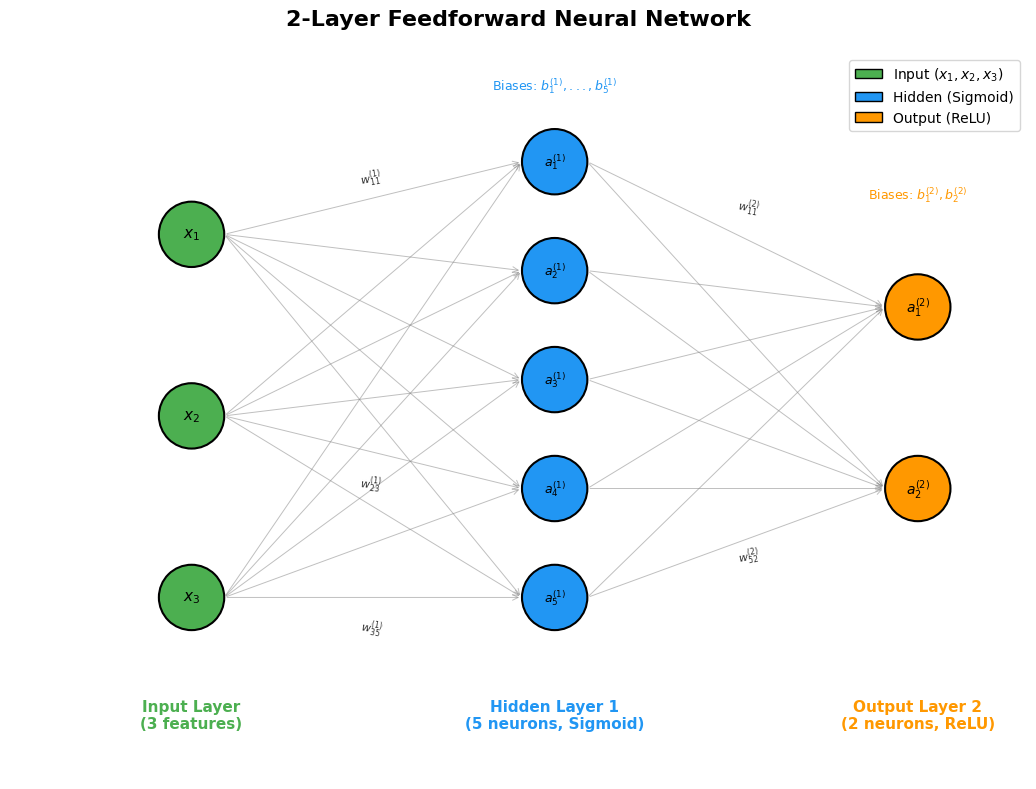

Network diagram saved.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_xlim(-1, 13)
ax.set_ylim(-1, 9)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("2-Layer Feedforward Neural Network", fontsize=16, fontweight='bold', pad=20)

# Layer positions
input_x, hidden_x, output_x = 1.5, 6.5, 11.5
input_neurons = [("$x_1$", 6.5), ("$x_2$", 4.0), ("$x_3$", 1.5)]
hidden_neurons = [("$a^{(1)}_1$", 7.5), ("$a^{(1)}_2$", 6.0), ("$a^{(1)}_3$", 4.5),
                  ("$a^{(1)}_4$", 3.0), ("$a^{(1)}_5$", 1.5)]
output_neurons = [("$a^{(2)}_1$", 5.5), ("$a^{(2)}_2$", 3.0)]

r = 0.45

# Draw neurons
for label, y in input_neurons:
    circle = plt.Circle((input_x, y), r, fill=True, facecolor='#4CAF50', edgecolor='black', linewidth=1.5, zorder=5)
    ax.add_patch(circle)
    ax.text(input_x, y, label, ha='center', va='center', fontsize=11, zorder=6)

for label, y in hidden_neurons:
    circle = plt.Circle((hidden_x, y), r, fill=True, facecolor='#2196F3', edgecolor='black', linewidth=1.5, zorder=5)
    ax.add_patch(circle)
    ax.text(hidden_x, y, label, ha='center', va='center', fontsize=9, zorder=6)

for label, y in output_neurons:
    circle = plt.Circle((output_x, y), r, fill=True, facecolor='#FF9800', edgecolor='black', linewidth=1.5, zorder=5)
    ax.add_patch(circle)
    ax.text(output_x, y, label, ha='center', va='center', fontsize=10, zorder=6)

# Draw connections with weight labels (sample a few)
for i, (_, iy) in enumerate(input_neurons):
    for j, (_, hy) in enumerate(hidden_neurons):
        ax.annotate('', xy=(hidden_x - r, hy), xytext=(input_x + r, iy),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.7, alpha=0.5))

for j, (_, hy) in enumerate(hidden_neurons):
    for k, (_, oy) in enumerate(output_neurons):
        ax.annotate('', xy=(output_x - r, oy), xytext=(hidden_x + r, hy),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.7, alpha=0.5))

# Weight labels (show a few representative ones)
ax.text(3.8, 7.2, "$w^{(1)}_{11}$", fontsize=8, color='#333', rotation=10)
ax.text(3.8, 3.0, "$w^{(1)}_{23}$", fontsize=8, color='#333', rotation=-5)
ax.text(3.8, 1.0, "$w^{(1)}_{35}$", fontsize=8, color='#333', rotation=-10)
ax.text(9.0, 6.8, "$w^{(2)}_{11}$", fontsize=8, color='#333', rotation=-10)
ax.text(9.0, 2.0, "$w^{(2)}_{52}$", fontsize=8, color='#333', rotation=10)

# Bias labels
ax.text(hidden_x, 8.5, "Biases: $b^{(1)}_1,...,b^{(1)}_5$", fontsize=9, ha='center', color='#2196F3')
ax.text(output_x, 7.0, "Biases: $b^{(2)}_1, b^{(2)}_2$", fontsize=9, ha='center', color='#FF9800')

# Layer labels
ax.text(input_x, -0.3, "Input Layer\n(3 features)", fontsize=11, ha='center', fontweight='bold', color='#4CAF50')
ax.text(hidden_x, -0.3, "Hidden Layer 1\n(5 neurons, Sigmoid)", fontsize=11, ha='center', fontweight='bold', color='#2196F3')
ax.text(output_x, -0.3, "Output Layer 2\n(2 neurons, ReLU)", fontsize=11, ha='center', fontweight='bold', color='#FF9800')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#4CAF50', edgecolor='black', label='Input ($x_1, x_2, x_3$)'),
    mpatches.Patch(facecolor='#2196F3', edgecolor='black', label='Hidden (Sigmoid)'),
    mpatches.Patch(facecolor='#FF9800', edgecolor='black', label='Output (ReLU)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('/nn_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Network diagram saved.")


### Part (ii): Forward Computation Equations

**Layer 1 (Hidden Layer — Sigmoid Activation)**

For each hidden neuron $j \in \{1,2,3,4,5\}$:

**Pre-activation (weighted sum):**
$$z^{(1)}_j = w^{(1)}_{1j} \cdot x_1 + w^{(1)}_{2j} \cdot x_2 + w^{(1)}_{3j} \cdot x_3 + b^{(1)}_j = \sum_{i=1}^{3} w^{(1)}_{ij} x_i + b^{(1)}_j$$

**Post-activation (sigmoid):**
$$a^{(1)}_j = \sigma(z^{(1)}_j) = \frac{1}{1 + e^{-z^{(1)}_j}}$$

**Expanded equations for each neuron:**

$$z^{(1)}_1 = w^{(1)}_{11} x_1 + w^{(1)}_{21} x_2 + w^{(1)}_{31} x_3 + b^{(1)}_1 \quad \Rightarrow \quad a^{(1)}_1 = \sigma(z^{(1)}_1)$$

$$z^{(1)}_2 = w^{(1)}_{12} x_1 + w^{(1)}_{22} x_2 + w^{(1)}_{32} x_3 + b^{(1)}_2 \quad \Rightarrow \quad a^{(1)}_2 = \sigma(z^{(1)}_2)$$

$$z^{(1)}_3 = w^{(1)}_{13} x_1 + w^{(1)}_{23} x_2 + w^{(1)}_{33} x_3 + b^{(1)}_3 \quad \Rightarrow \quad a^{(1)}_3 = \sigma(z^{(1)}_3)$$

$$z^{(1)}_4 = w^{(1)}_{14} x_1 + w^{(1)}_{24} x_2 + w^{(1)}_{34} x_3 + b^{(1)}_4 \quad \Rightarrow \quad a^{(1)}_4 = \sigma(z^{(1)}_4)$$

$$z^{(1)}_5 = w^{(1)}_{15} x_1 + w^{(1)}_{25} x_2 + w^{(1)}_{35} x_3 + b^{(1)}_5 \quad \Rightarrow \quad a^{(1)}_5 = \sigma(z^{(1)}_5)$$

In matrix form: $\mathbf{z}^{(1)} = \mathbf{W}^{(1)T} \mathbf{x} + \mathbf{b}^{(1)}$, $\quad \mathbf{a}^{(1)} = \sigma(\mathbf{z}^{(1)})$

where $\mathbf{W}^{(1)} \in \mathbb{R}^{3 \times 5}$, $\mathbf{b}^{(1)} \in \mathbb{R}^{5}$

---

**Layer 2 (Output Layer — ReLU Activation)**

For each output neuron $k \in \{1,2\}$:

**Pre-activation:**
$$z^{(2)}_k = \sum_{j=1}^{5} w^{(2)}_{jk} \cdot a^{(1)}_j + b^{(2)}_k$$

**Post-activation (ReLU):**
$$a^{(2)}_k = \text{ReLU}(z^{(2)}_k) = \max(0, z^{(2)}_k)$$

**Expanded:**

$$z^{(2)}_1 = w^{(2)}_{11} a^{(1)}_1 + w^{(2)}_{21} a^{(1)}_2 + w^{(2)}_{31} a^{(1)}_3 + w^{(2)}_{41} a^{(1)}_4 + w^{(2)}_{51} a^{(1)}_5 + b^{(2)}_1 \quad \Rightarrow \quad a^{(2)}_1 = \text{ReLU}(z^{(2)}_1)$$

$$z^{(2)}_2 = w^{(2)}_{12} a^{(1)}_1 + w^{(2)}_{22} a^{(1)}_2 + w^{(2)}_{32} a^{(1)}_3 + w^{(2)}_{42} a^{(1)}_4 + w^{(2)}_{52} a^{(1)}_5 + b^{(2)}_2 \quad \Rightarrow \quad a^{(2)}_2 = \text{ReLU}(z^{(2)}_2)$$

In matrix form: $\mathbf{z}^{(2)} = \mathbf{W}^{(2)T} \mathbf{a}^{(1)} + \mathbf{b}^{(2)}$, $\quad \mathbf{a}^{(2)} = \text{ReLU}(\mathbf{z}^{(2)})$

where $\mathbf{W}^{(2)} \in \mathbb{R}^{5 \times 2}$, $\mathbf{b}^{(2)} \in \mathbb{R}^{2}$

**Final output:** $\mathbf{y} = \mathbf{a}^{(2)} = [a^{(2)}_1, a^{(2)}_2]$


## Question 7 [25 Points]

**MNIST Handwritten Digit Classification using Neural Networks**

Implement a neural network for digit classification (0–9) on the provided MNIST CSV dataset. Compare a 3-layer NN and a 4-layer NN.

---

### Part (i): Network Design and Hyperparameters [5 Points]


In [10]:
# ============================================================
# Q7 Part (i): Network Design & Hyperparameters
# ============================================================

print("=" * 65)
print("NETWORK ARCHITECTURES & HYPERPARAMETERS")
print("=" * 65)

print("""
3-Layer Neural Network:
  - Input Layer:  784 neurons (28x28 pixel images, flattened)
  - Hidden Layer: 128 neurons, ReLU activation
  - Output Layer: 10 neurons, Softmax activation

4-Layer Neural Network:
  - Input Layer:    784 neurons (28x28 pixel images, flattened)
  - Hidden Layer 1: 256 neurons, ReLU activation
  - Hidden Layer 2: 128 neurons, ReLU activation
  - Output Layer:   10 neurons, Softmax activation

Common Hyperparameters:
  - Optimizer:      Adam (lr = 0.001)
  - Loss Function:  Categorical Cross-Entropy (SparseCategoricalCrossentropy)
  - Batch Size:     32
  - Epochs:         100
  - Train/Test:     80% / 20% random split
  - Input Scaling:  Pixel values normalized to [0, 1]
""")


NETWORK ARCHITECTURES & HYPERPARAMETERS

3-Layer Neural Network:
  - Input Layer:  784 neurons (28x28 pixel images, flattened)
  - Hidden Layer: 128 neurons, ReLU activation
  - Output Layer: 10 neurons, Softmax activation

4-Layer Neural Network:
  - Input Layer:    784 neurons (28x28 pixel images, flattened)
  - Hidden Layer 1: 256 neurons, ReLU activation
  - Hidden Layer 2: 128 neurons, ReLU activation
  - Output Layer:   10 neurons, Softmax activation

Common Hyperparameters:
  - Optimizer:      Adam (lr = 0.001)
  - Loss Function:  Categorical Cross-Entropy (SparseCategoricalCrossentropy)
  - Batch Size:     32
  - Epochs:         100
  - Train/Test:     80% / 20% random split
  - Input Scaling:  Pixel values normalized to [0, 1]



CSV file not found. Please upload 'Assignment_2_-_MINST.csv':


Saving Assignment 2 - MINST.csv to Assignment 2 - MINST (1).csv
Loaded CSV from: Assignment 2 - MINST (1).csv
Dataset shape: (999, 785)
Number of samples: 999
Number of features (pixels): 784
Class distribution:
label
0    100
1    100
2    100
3    100
4    100
5    100
6     99
7    100
8    100
9    100
Name: count, dtype: int64

Training samples: 799
Testing samples:  200


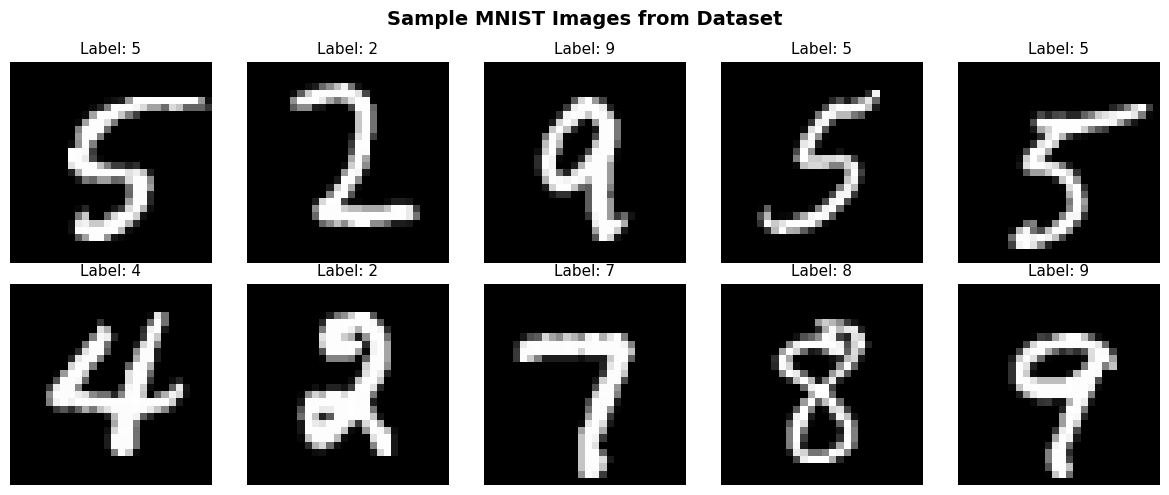

In [11]:
# ============================================================
# Data Loading & Preprocessing
# ============================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Suppress TF warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# ---- LOAD CSV ----
# Try multiple possible paths for the MNIST CSV file.
# If running in Google Colab, upload the file or mount Google Drive.
import os

possible_paths = [
    'Assignment_2_-_MINST.csv',                              # same directory
    './Assignment_2_-_MINST.csv',                             # current dir explicit
    '/content/Assignment_2_-_MINST.csv',                      # Colab default
    '/content/drive/MyDrive/Assignment_2_-_MINST.csv',        # Colab Google Drive
    '/mnt/user-data/uploads/Assignment_2_-_MINST.csv',        # Claude environment
]

csv_path = None
for path in possible_paths:
    if os.path.exists(path):
        csv_path = path
        break

if csv_path is None:
    # If running in Colab, try uploading
    try:
        from google.colab import files
        print("CSV file not found. Please upload 'Assignment_2_-_MINST.csv':")
        uploaded = files.upload()
        csv_path = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "Could not find 'Assignment_2_-_MINST.csv'. "
            "Please place it in the same directory as this notebook, "
            "or update the path in the cell above."
        )

data = pd.read_csv(csv_path)
print(f"Loaded CSV from: {csv_path}")
print(f"Dataset shape: {data.shape}")
print(f"Number of samples: {data.shape[0]}")
print(f"Number of features (pixels): {data.shape[1] - 1}")
print(f"Class distribution:\n{data['label'].value_counts().sort_index()}")

# Separate features and labels
X = data.iloc[:, 1:].values.astype('float32') / 255.0  # Normalize to [0, 1]
y = data.iloc[:, 0].values

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample MNIST Images from Dataset", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# Build and Train 3-Layer Neural Network
# ============================================================
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 65)
print("3-LAYER NEURAL NETWORK (Input → Hidden(128) → Output(10))")
print("=" * 65)

# Build model
model_3layer = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="3_Layer_NN")

model_3layer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_3layer.summary()

# Train
history_3layer = model_3layer.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

# Print final metrics
train_loss_3 = history_3layer.history['loss'][-1]
test_loss_3 = history_3layer.history['val_loss'][-1]
train_acc_3 = history_3layer.history['accuracy'][-1]
test_acc_3 = history_3layer.history['val_accuracy'][-1]

print(f"\nFinal Training Loss:    {train_loss_3:.4f}")
print(f"Final Training Accuracy: {train_acc_3*100:.2f}%")
print(f"Final Test Loss:         {test_loss_3:.4f}")
print(f"Final Test Accuracy:     {test_acc_3*100:.2f}%")


3-LAYER NEURAL NETWORK (Input → Hidden(128) → Output(10))


Model: "3_Layer_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Final Training Loss:    0.0007
Final Training Accuracy: 100.00%
Final Test Loss:         0.4993
Final Test Accuracy:     89.00%


In [13]:
# ============================================================
# Build and Train 4-Layer Neural Network
# ============================================================

print("=" * 65)
print("4-LAYER NEURAL NETWORK (Input → Hidden(256) → Hidden(128) → Output(10))")
print("=" * 65)

model_4layer = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="4_Layer_NN")

model_4layer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_4layer.summary()

# Train
history_4layer = model_4layer.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

# Print final metrics
train_loss_4 = history_4layer.history['loss'][-1]
test_loss_4 = history_4layer.history['val_loss'][-1]
train_acc_4 = history_4layer.history['accuracy'][-1]
test_acc_4 = history_4layer.history['val_accuracy'][-1]

print(f"\nFinal Training Loss:    {train_loss_4:.4f}")
print(f"Final Training Accuracy: {train_acc_4*100:.2f}%")
print(f"Final Test Loss:         {test_loss_4:.4f}")
print(f"Final Test Accuracy:     {test_acc_4*100:.2f}%")


4-LAYER NEURAL NETWORK (Input → Hidden(256) → Hidden(128) → Output(10))


Model: "4_Layer_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)


Final Training Loss:    0.0001
Final Training Accuracy: 100.00%
Final Test Loss:         0.5393
Final Test Accuracy:     89.50%


### Part (ii): Training and Testing Error Curves [10 Points]

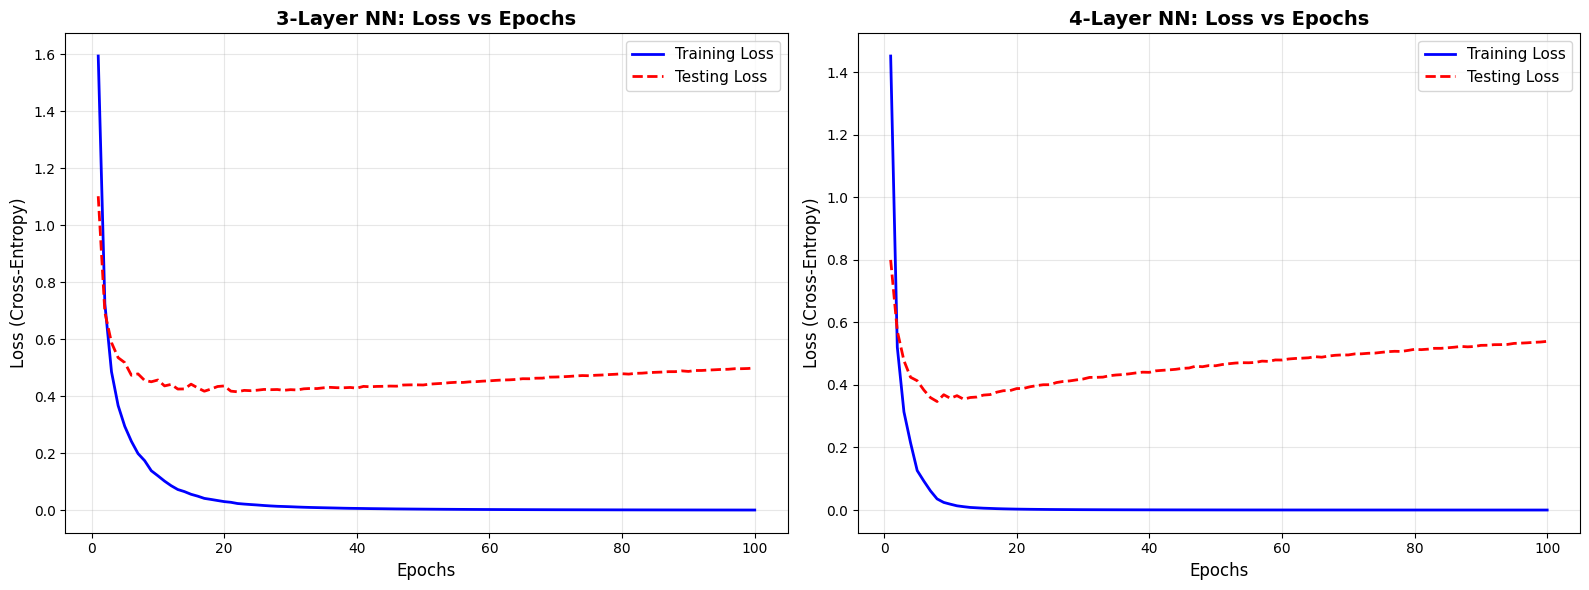

Loss curves saved.


In [15]:
# ============================================================
# Q7 Part (ii): Error (Loss) Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3-Layer NN Loss Curves
ax1 = axes[0]
epochs = range(1, 101)
ax1.plot(epochs, history_3layer.history['loss'], 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, history_3layer.history['val_loss'], 'r--', label='Testing Loss', linewidth=2)
ax1.set_title('3-Layer NN: Loss vs Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 4-Layer NN Loss Curves
ax2 = axes[1]
ax2.plot(epochs, history_4layer.history['loss'], 'b-', label='Training Loss', linewidth=2)
ax2.plot(epochs, history_4layer.history['val_loss'], 'r--', label='Testing Loss', linewidth=2)
ax2.set_title('4-Layer NN: Loss vs Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curves saved.")


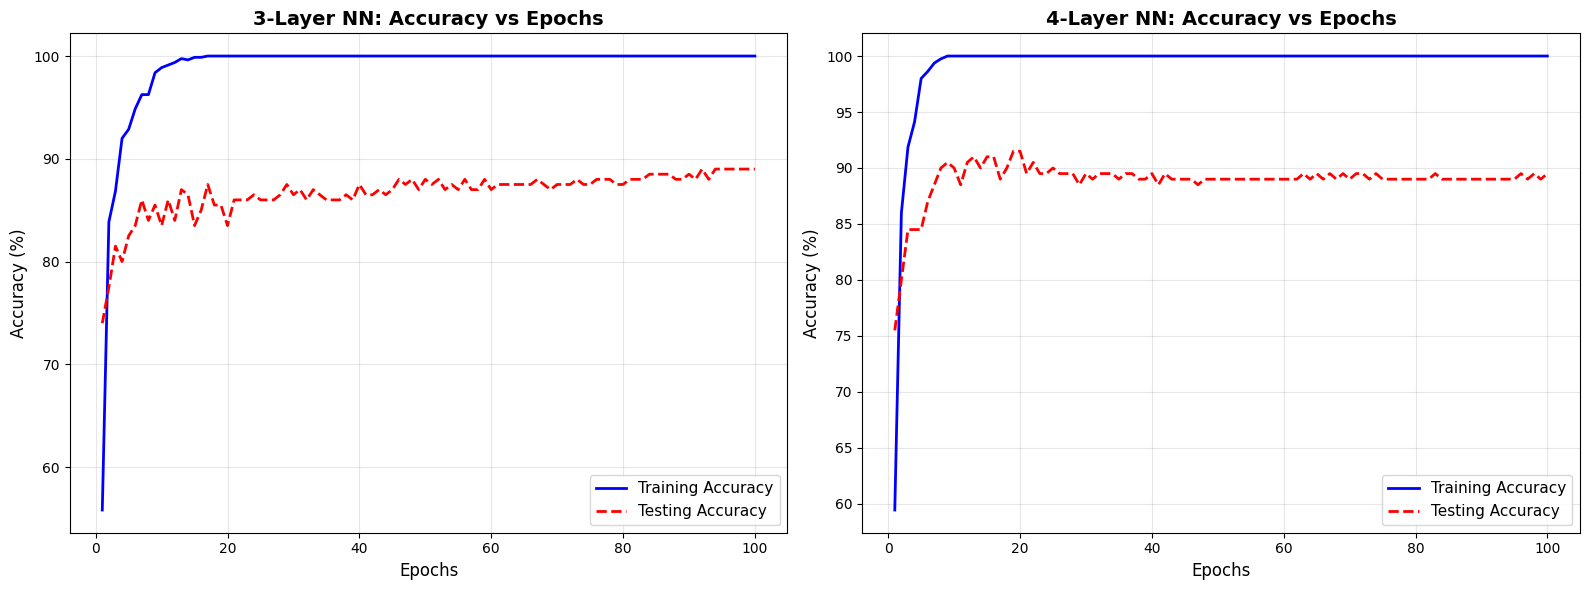

Accuracy curves saved.


In [16]:
# ============================================================
# Accuracy Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot(epochs, [a*100 for a in history_3layer.history['accuracy']], 'b-', label='Training Accuracy', linewidth=2)
ax1.plot(epochs, [a*100 for a in history_3layer.history['val_accuracy']], 'r--', label='Testing Accuracy', linewidth=2)
ax1.set_title('3-Layer NN: Accuracy vs Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(epochs, [a*100 for a in history_4layer.history['accuracy']], 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, [a*100 for a in history_4layer.history['val_accuracy']], 'r--', label='Testing Accuracy', linewidth=2)
ax2.set_title('4-Layer NN: Accuracy vs Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Accuracy curves saved.")


### Part (iii): Test Accuracy Comparison and Discussion [10 Points]

In [17]:
# ============================================================
# Q7 Part (iii): Test Accuracy Comparison
# ============================================================

print("=" * 65)
print("TEST ACCURACY COMPARISON")
print("=" * 65)

# Evaluate both models
loss_3, acc_3 = model_3layer.evaluate(X_test, y_test, verbose=0)
loss_4, acc_4 = model_4layer.evaluate(X_test, y_test, verbose=0)

print(f"\n{'Model':<25} | {'Test Loss':>10} | {'Test Accuracy':>15}")
print("-" * 60)
print(f"{'3-Layer NN':<25} | {loss_3:>10.4f} | {acc_3*100:>14.2f}%")
print(f"{'4-Layer NN':<25} | {loss_4:>10.4f} | {acc_4*100:>14.2f}%")
print("-" * 60)

print(f"""
DISCUSSION:

Both neural networks are trained on a relatively small MNIST subset
(~800 training samples, ~200 test samples) for 100 epochs.

3-Layer NN (784 → 128 → 10):
  - Parameters: {model_3layer.count_params():,}
  - Simpler architecture with one hidden layer
  - Less prone to overfitting on small datasets
  - Test accuracy: {acc_3*100:.2f}%

4-Layer NN (784 → 256 → 128 → 10):
  - Parameters: {model_4layer.count_params():,}
  - Deeper architecture with two hidden layers
  - Greater model capacity to learn complex features
  - Test accuracy: {acc_4*100:.2f}%

Key observations:
1. With a small dataset (1000 total images), the 4-layer network has
   significantly more parameters and higher capacity, which can lead
   to overfitting — it may memorize training data rather than generalize.

2. The 3-layer network, being simpler, may generalize better on this
   small dataset due to fewer parameters (less overfitting risk).

3. On larger MNIST datasets (60K samples), deeper networks typically
   outperform shallower ones because the extra capacity helps learn
   more abstract features without overfitting.

4. Both models use the Adam optimizer and Softmax output, ensuring
   proper probability distributions over 10 digit classes.
""")


TEST ACCURACY COMPARISON

Model                     |  Test Loss |   Test Accuracy
------------------------------------------------------------
3-Layer NN                |     0.4993 |          89.00%
4-Layer NN                |     0.5393 |          89.50%
------------------------------------------------------------

DISCUSSION:

Both neural networks are trained on a relatively small MNIST subset 
(~800 training samples, ~200 test samples) for 100 epochs.

3-Layer NN (784 → 128 → 10):
  - Parameters: 101,770
  - Simpler architecture with one hidden layer
  - Less prone to overfitting on small datasets
  - Test accuracy: 89.00%

4-Layer NN (784 → 256 → 128 → 10):
  - Parameters: 235,146
  - Deeper architecture with two hidden layers
  - Greater model capacity to learn complex features
  - Test accuracy: 89.50%

Key observations:
1. With a small dataset (1000 total images), the 4-layer network has 
   significantly more parameters and higher capacity, which can lead 
   to overfitting —

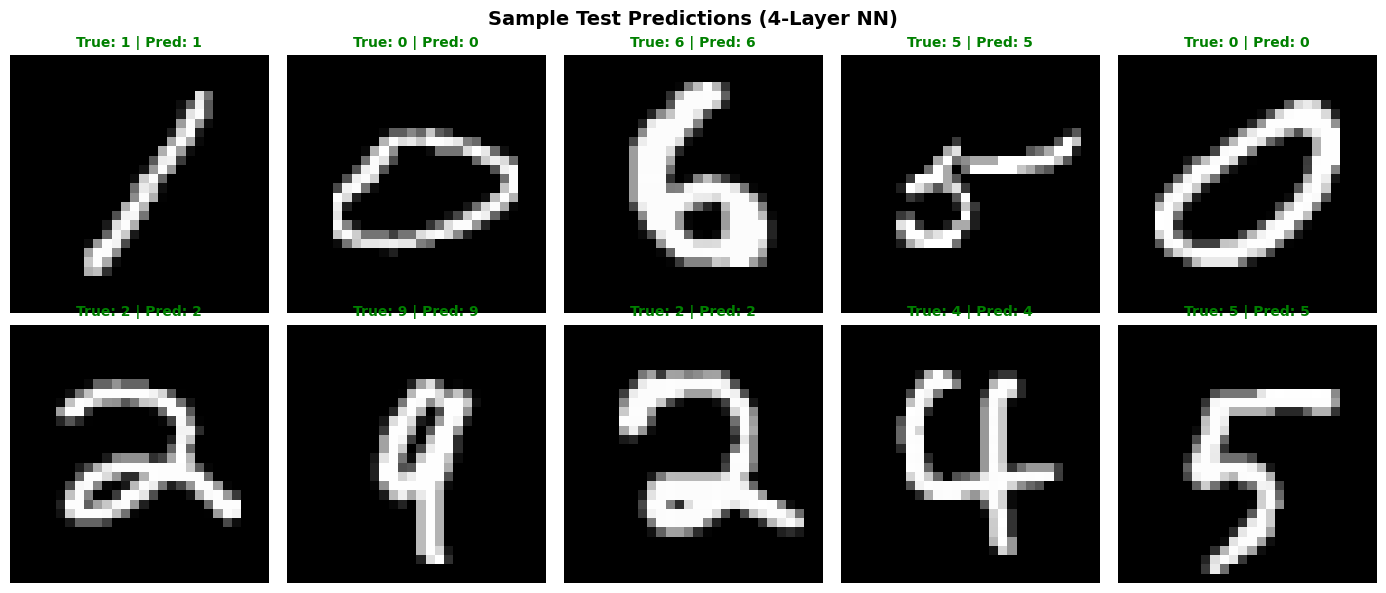

Green = Correct, Red = Incorrect


In [19]:
# ============================================================
# Sample Predictions (visual verification)
# ============================================================
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Test Predictions (4-Layer NN)", fontsize=14, fontweight='bold')

predictions = model_4layer.predict(X_test[:10], verbose=0)
pred_labels = np.argmax(predictions, axis=1)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if pred_labels[i] == y_test[i] else 'red'
    ax.set_title(f"True: {y_test[i]} | Pred: {pred_labels[i]}",
                 fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Green = Correct, Red = Incorrect")
